### Analiza sentymentu na podstawie recenzji aplikacji Spotify​

Zbiór danych: https://www.kaggle.com/datasets/mfaaris/spotify-app-reviews-2022

Dane zawierają zbiór recenzji aplikacji Spotify w raz z jej oceną.

Cel analizy: Otrzymanie modelu, który na podstawie treści recenzji będzie potrafił poprawnie ją zaklasyfikować do jednej z trzech klas opinii: pozytywne, neutralne, negatywne

In [1]:
#Biblioteki używane w projekcie
import os
import sys
import pandas as pd
import nltk
from nltk.corpus import stopwords
import re
import seaborn as sns
import matplotlib.pyplot as plt
from collections import  Counter
import spacy
from tqdm import tqdm
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.stem.snowball import SnowballStemmer
from sklearn.model_selection import train_test_split
from textblob import TextBlob
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import numpy as np
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ShuffleSplit, cross_val_score

In [2]:
from zipfile import ZipFile
zip_projekt = ZipFile('reviews.csv.zip')
zip_projekt.extractall()

In [3]:
os.getcwd()

'/home/mion/s/60/dwisniew'

In [4]:
spotify = pd.read_csv("/home/mion/s/60/dwisniew/reviews.csv", sep = ",")

In [5]:
#Podgląd danych
spotify.head(10)

,Time_submitted,Review,Rating,Total_thumbsup,Reply
0,2022-07-09 15:00:00,"Great music service, the audio is high quality...",5,2,NaN
1,2022-07-09 14:21:22,Please ignore previous negative rating. This a...,5,1,NaN
2,2022-07-09 13:27:32,"This pop-up ""Get the best Spotify experience o...",4,0,NaN
3,2022-07-09 13:26:45,Really buggy and terrible to use as of recently,1,1,NaN
4,2022-07-09 13:20:49,Dear Spotify why do I get songs that I didn't ...,1,1,NaN
5,2022-07-09 13:20:20,The player controls sometimes disappear for no...,3,7,NaN
6,2022-07-09 13:19:21,I love the selection and the lyrics are provid...,5,0,NaN
7,2022-07-09 13:17:22,Still extremely slow when changing storage to ...,3,16,NaN
8,2022-07-09 13:16:49,It's a great app and the best mp3 music app I ...,5,0,NaN
9,2022-07-09 13:11:32,"I'm deleting this app, for the following reaso...",1,318,NaN


In [6]:
#Usunięcie kolumny Time_submitted, Total_thumbsup, Reply - niepotrzebnych do analizy
columns_to_delete = ['Time_submitted','Total_thumbsup', 'Reply']
spotify = spotify.drop(columns=columns_to_delete)

### Wstępna eksploracja
- rozkład ocen recenzji
- rozkład liczby znaków w recenzjach
- rozkład liczby słów w recenzjach
- sprawdzenie czy występują recenzje bez treści
- rozkład najczęściej występujących słów w korpusie

#### Rozkład ocen recenzji

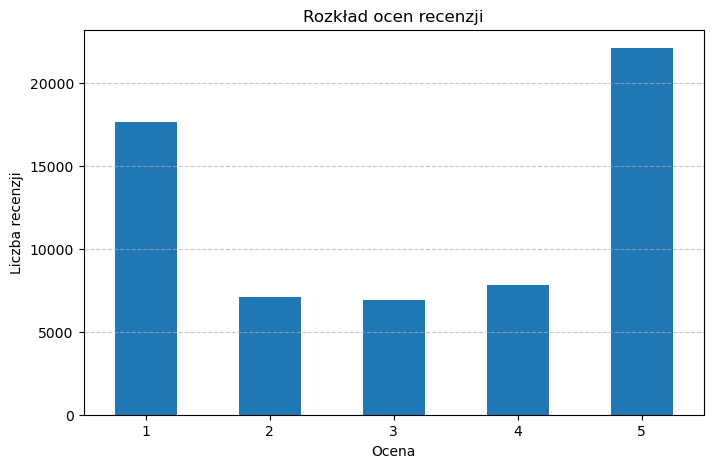

In [7]:
plt.figure(figsize=(8, 5))
spotify['Rating'].value_counts(sort=False).sort_index().plot(kind='bar')
plt.title("Rozkład ocen recenzji")
plt.xlabel("Ocena")
plt.ylabel("Liczba recenzji")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Ocena 1 (najniższa) oraz 5 (najwyższa) są najczęściej wystawiane, natomiast oceny 2, 3 i 4 są mniej liczne.

#### Rozkład liczby znaków w recenzjach

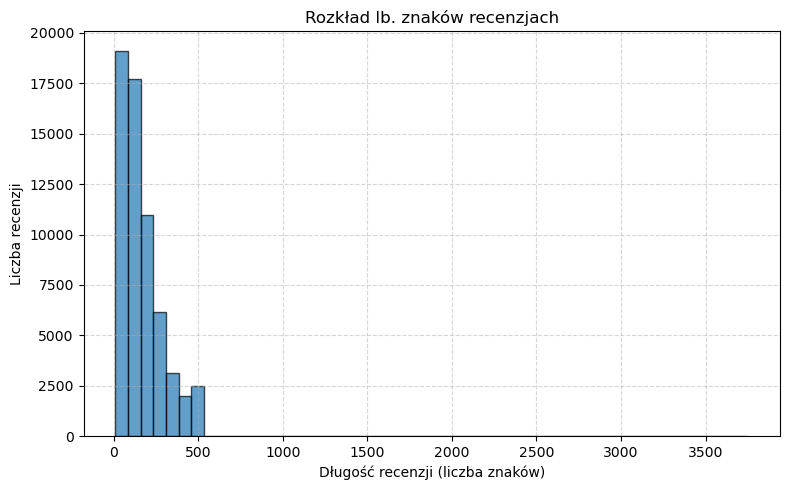

Standardowa szerokość kolumn: 150 znaków


In [8]:
plt.figure(figsize=(8, 5))
spotify['Review'].str.len().hist(bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Długość recenzji (liczba znaków)')
plt.ylabel('Liczba recenzji')
plt.title('Rozkład lb. znaków recenzjach')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

pd.set_option('display.max_colwidth', 150)
print(f"Standardowa szerokość kolumn: {pd.get_option('display.max_colwidth')} znaków")
plt.show()

Najwięcej recenzji (dominująca część danych) jest bardzo krótka i ma poniżej 250 znaków.

In [9]:
average_length = spotify['Review'].str.len().mean()
print(f"Średnia liczba znaków w recenzjach: {average_length:.2f}")

Średnia liczba znaków w recenzjach: 163.32


In [10]:
pd.set_option('display.max_colwidth', 500)
spotify.head(10)

,Review,Rating
0,"Great music service, the audio is high quality and the app is easy to use. Also very quick and friendly support.",5
1,Please ignore previous negative rating. This app is super great. I give it five stars+,5
2,"This pop-up ""Get the best Spotify experience on Android 12"" is too annoying. Please let's get rid of this.",4
3,Really buggy and terrible to use as of recently,1
4,Dear Spotify why do I get songs that I didn't put on my playlist??? And why do we have shuffle play?,1
5,The player controls sometimes disappear for no reason. App restart forgets what I was playing but fixes the issue.,3
6,I love the selection and the lyrics are provided with the song you're listening to!,5
7,"Still extremely slow when changing storage to external sd card.. I'm convinced this is done on purpose, spotify knows of this issue and has done NOTHING to solve it! Over time I have changed sd cards, each being faster in read, write speeds(all samsung brand). And please add ""don't like song"" so it will never appear again in my searches or playlists.",3
8,"It's a great app and the best mp3 music app I have ever used but there is one problem that, why can't we play some songs or find some songs? despite this the app is wonderful I recommend it. it's just the best.",5
9,"I'm deleting this app, for the following reasons: This app now has a failing business model. Whether streaming services like it, or not: the consumer doesn't want to pay for music they can't fully own, and 6 ads successively, upon logging in, before a single song, is too much. Closed the app during ad number 6, and I'm more patient than most. If those are the only ways you can profit: you've already peaked. All that's left is your decline.",1


#### Rozkład liczby słów w recenzjach

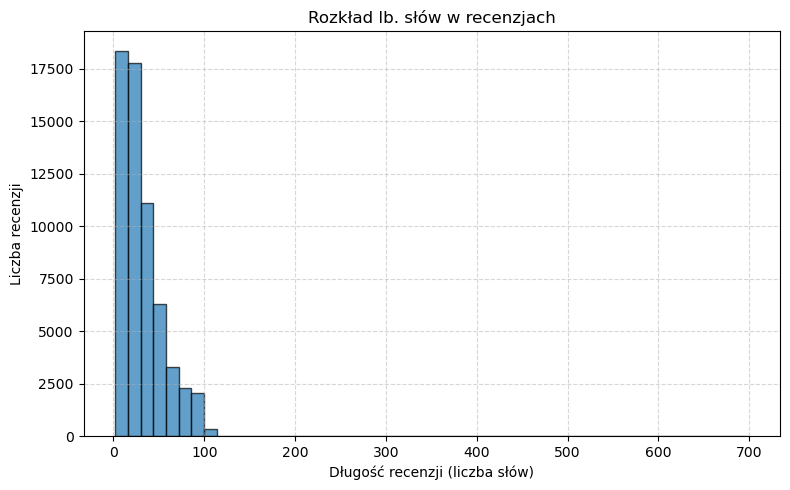

0    21
1    15
2    19
3     9
4    21
5    19
6    15
7    62
8    43
9    80
Name: Review, dtype: int64

In [11]:
plt.figure(figsize=(8, 5))
word_count = spotify['Review'].str.split().map(lambda x: len(x))
word_count.hist(bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Długość recenzji (liczba słów)')
plt.ylabel('Liczba recenzji')
plt.title('Rozkład lb. słów w recenzjach')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
word_count.head(10)

Najwięcej recenzji jest krótka i ma poniżej 50 słów.

In [12]:
#Podstawowe statystyki dotyczące ilości słów
word_count.describe()

count    61594.000000
mean        30.886223
std         22.743188
min          2.000000
25%         14.000000
50%         25.000000
75%         42.000000
max        699.000000
Name: Review, dtype: float64

Lb. recencji: 61594

Śr. ilość słów w recenzjach: 31

Min. ilość słów w recencji: 2

Max. ilość słów w recencji: 699

#### Spawdzenie czy występują recenzje bez treści

In [13]:
empty_reviews = spotify['Review'].str.strip().str.len() == 0

empty_reviews_df = spotify[empty_reviews]
print("Liczba pustych recenzji:", empty_reviews_df.shape[0])
print(empty_reviews_df)

Liczba pustych recenzji: 0
Empty DataFrame
Columns: [Review, Rating]
Index: []


#### Rozkład najczęściej występujących słów w korpusie

In [14]:
#Storzenie korpusu na surowych danych - listy słów występujących we wszystkich recencjach
corpus = []
for x in spotify["Review"].str.split():
    corpus.extend(x)

In [15]:
#Analiza korpusu pod względem najczęściej występujących słowa i zliczenie ich występowania ('słowo', jego liczba wystąpień)
counter=Counter(corpus)
most=counter.most_common()

In [16]:
#Stworzenie listy 40 najczęściej występujących słów w korpusie
first_n = 40
x, y= [], []
for word,count in most[:first_n]:
        x.append(word)
        y.append(count)

40 najczęściej występujących słów w korpusie


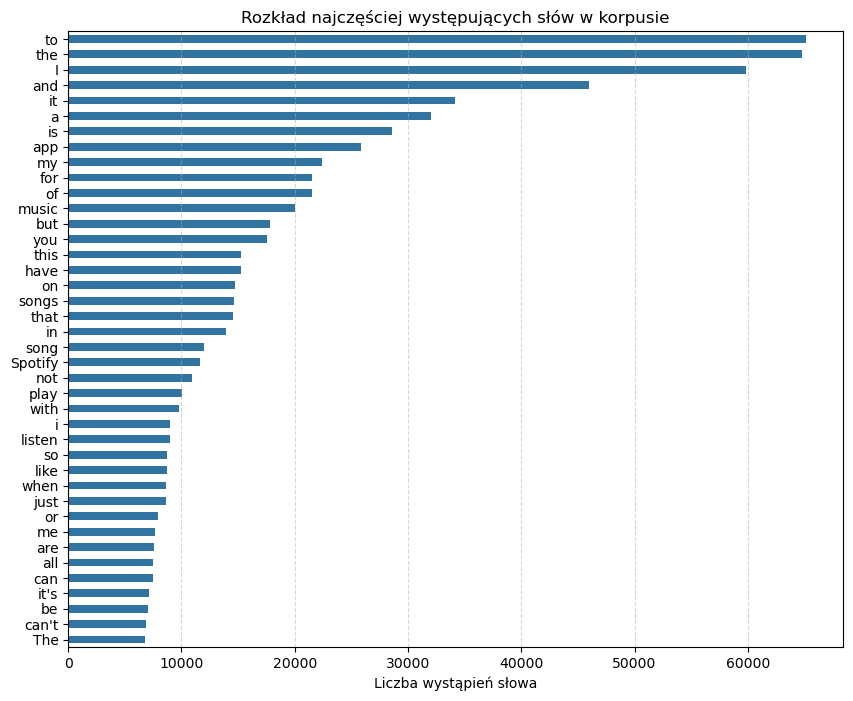

In [17]:
#Stworzenie wykresu najczęściej występujących słów w korpusie
plt.figure(figsize=(10, 8))
sns.barplot(x=y,y=x, width=0.5)
plt.xlabel('Liczba wystąpień słowa')
plt.title('Rozkład najczęściej występujących słów w korpusie')
plt.grid(axis='x', linestyle='--', alpha=0.5)
print(f"{first_n} najczęściej występujących słów w korpusie")
plt.show()

W większości są to stopwordsy, czyli słowa, które nie niosa żadnego znaczenia i które zapewne będzie trzeba wyłączyć z dalszej analizy.

### Przetwarzanie tekstu z kolumny Review
- czyszczenie danych
- tokenizacja na słowa
- stemming i lametyzacja
- zdefiniowanie i usunięcie stopwordsów

#### Czyszczenie danych

In [18]:
#Zdefiniowanie funkcji do czyszczenia teksu
def preprocessor(text):
    text = re.sub('<[^>]*>', '', text)
    emoticons = re.findall('(?::|;|=)(?:-)?(?:\)|\(|D|P)', text)
    text = re.sub(r"[^\w\s\']", ' ', text.lower()) +\
        ' '.join(emoticons).replace('-', '')
    return text

Zdecydowałam się zachować apostrofy w słowach, które mogą mieć znaczący wpływ w segmentacji recenzji min.in. w identyfikacji zaprzeczeń, które prawdopodobnie będą miały kluczowe znaczenie w sentymentacji negatywnych opinni. 

In [19]:
#Sprawdzenie tekstu po oczyszczeniu
example = spotify.loc[4, 'Review'][0:165]

In [20]:
print(f"Oryginalny tekst: \n{example}")
print("\n")
print(f"Po oczyszczeniu: \n{preprocessor(example)}")

Oryginalny tekst: 
Dear Spotify why do I get songs that I didn't put on my playlist??? And why do we have shuffle play?


Po oczyszczeniu: 
dear spotify why do i get songs that i didn't put on my playlist    and why do we have shuffle play 


In [21]:
#Zapisanie oczyszczonego teksu recenzji w oddzielnej kolumnie
spotify["review_clean"] = spotify['Review'].apply(preprocessor)
spotify.head(5)

,Review,Rating,review_clean
0,"Great music service, the audio is high quality and the app is easy to use. Also very quick and friendly support.",5,great music service the audio is high quality and the app is easy to use also very quick and friendly support
1,Please ignore previous negative rating. This app is super great. I give it five stars+,5,please ignore previous negative rating this app is super great i give it five stars
2,"This pop-up ""Get the best Spotify experience on Android 12"" is too annoying. Please let's get rid of this.",4,this pop up get the best spotify experience on android 12 is too annoying please let's get rid of this
3,Really buggy and terrible to use as of recently,1,really buggy and terrible to use as of recently
4,Dear Spotify why do I get songs that I didn't put on my playlist??? And why do we have shuffle play?,1,dear spotify why do i get songs that i didn't put on my playlist and why do we have shuffle play


#### Tokenizacja na słowa

In [22]:
#Sprawdzenie tokenizatora word_tokenize z biblioteki NLTK na oczyszconych danych
example = spotify["review_clean"][4]
print("Przed tokenizacją na słowa:")
print(example)
print("\n")
print("Tokenizacja na słowa:")
print(word_tokenize(example))

Przed tokenizacją na słowa:
dear spotify why do i get songs that i didn't put on my playlist    and why do we have shuffle play 


Tokenizacja na słowa:
['dear', 'spotify', 'why', 'do', 'i', 'get', 'songs', 'that', 'i', 'did', "n't", 'put', 'on', 'my', 'playlist', 'and', 'why', 'do', 'we', 'have', 'shuffle', 'play']


Tokenizator z biblioteki NLTK rozdziela słowa zawierające apostrof np didn't na "did" i "n't", który zdecydowałam się zostawić podczas oczyszczania danych, aby zachować kontekst zaprzeczeń. Zdefiniuje własny tokenizator, aby nie rozdziolał słów z apostrofem. 

In [23]:
#Zdefiniowanie i sprawdzenie tokenizatora wykorzystującego wyrażenie regularne
def regex_tokenize(text):
    return re.findall(r"\b\w+(?:'\w+)?\b", text)

example = spotify["review_clean"][4]
print("Przed tokenizacją na słowa:")
print(example)
print("\n")
print("Tokenizacja na słowa:")
print(regex_tokenize(example))

Przed tokenizacją na słowa:
dear spotify why do i get songs that i didn't put on my playlist    and why do we have shuffle play 


Tokenizacja na słowa:
['dear', 'spotify', 'why', 'do', 'i', 'get', 'songs', 'that', 'i', "didn't", 'put', 'on', 'my', 'playlist', 'and', 'why', 'do', 'we', 'have', 'shuffle', 'play']


In [24]:
#Zastosowanie zdefiniowanego tokenizatora
tqdm.pandas()
spotify["review_tokenised_regex"] = spotify['review_clean'].progress_apply(regex_tokenize)

100%|██████████| 61594/61594 [00:01<00:00, 54280.62it/s]


In [25]:
spotify.head(5)

,Review,Rating,review_clean,review_tokenised_regex
0,"Great music service, the audio is high quality and the app is easy to use. Also very quick and friendly support.",5,great music service the audio is high quality and the app is easy to use also very quick and friendly support,"[great, music, service, the, audio, is, high, quality, and, the, app, is, easy, to, use, also, very, quick, and, friendly, support]"
1,Please ignore previous negative rating. This app is super great. I give it five stars+,5,please ignore previous negative rating this app is super great i give it five stars,"[please, ignore, previous, negative, rating, this, app, is, super, great, i, give, it, five, stars]"
2,"This pop-up ""Get the best Spotify experience on Android 12"" is too annoying. Please let's get rid of this.",4,this pop up get the best spotify experience on android 12 is too annoying please let's get rid of this,"[this, pop, up, get, the, best, spotify, experience, on, android, 12, is, too, annoying, please, let's, get, rid, of, this]"
3,Really buggy and terrible to use as of recently,1,really buggy and terrible to use as of recently,"[really, buggy, and, terrible, to, use, as, of, recently]"
4,Dear Spotify why do I get songs that I didn't put on my playlist??? And why do we have shuffle play?,1,dear spotify why do i get songs that i didn't put on my playlist and why do we have shuffle play,"[dear, spotify, why, do, i, get, songs, that, i, didn't, put, on, my, playlist, and, why, do, we, have, shuffle, play]"


#### Stemming i lematyzacja

In [26]:
#Sprawdzenie stemmingu za pomocą PorterStemmer z biblioteki NLTK
porter = PorterStemmer()

def stem_porter(tokens):
    return [porter.stem(token) for token in tokens]

example = spotify["review_tokenised_regex"][4]
print("Przed stemmingiem:")
print(example)
print("\n")
print("Po stemmingu:")
print(stem_porter(example))

Przed stemmingiem:
['dear', 'spotify', 'why', 'do', 'i', 'get', 'songs', 'that', 'i', "didn't", 'put', 'on', 'my', 'playlist', 'and', 'why', 'do', 'we', 'have', 'shuffle', 'play']


Po stemmingu:
['dear', 'spotifi', 'whi', 'do', 'i', 'get', 'song', 'that', 'i', "didn't", 'put', 'on', 'my', 'playlist', 'and', 'whi', 'do', 'we', 'have', 'shuffl', 'play']


Wynik stemmingu za pomocą PorterStemmer z biblioteki NLTK nie jest dla mnie zadowalający ponieważ słowa kończące się na 'y' są modyfikowane i 'y' zamieniany jest na 'i', dlatego dodatkowo przetestuje SnowballStemmer z biblioteki NLTK.

In [27]:
#Sprawdzenie stemmingu za pomocą SnowballStemmer z biblioteki NLTK
snowball = SnowballStemmer("english")

def stem_snowball(tokens):
    return [snowball.stem(token) for token in tokens]

example = spotify["review_tokenised_regex"][4]
print("Przed stemmingiem:")
print(example)
print("\n")
print("Po stemmingu:")
print( stem_snowball(example))

Przed stemmingiem:
['dear', 'spotify', 'why', 'do', 'i', 'get', 'songs', 'that', 'i', "didn't", 'put', 'on', 'my', 'playlist', 'and', 'why', 'do', 'we', 'have', 'shuffle', 'play']


Po stemmingu:
['dear', 'spotifi', 'whi', 'do', 'i', 'get', 'song', 'that', 'i', "didn't", 'put', 'on', 'my', 'playlist', 'and', 'whi', 'do', 'we', 'have', 'shuffl', 'play']


In [28]:
#Sprawdzenie lametyzacji za pomocą WordNetLemmatizer z biblioteki NLTK
WordNetLem = WordNetLemmatizer()

def lem_WordNet(tokens):
    return [WordNetLem.lemmatize(token) for token in tokens]
example = spotify["review_tokenised_regex"][4]
print("Przed lametyzacją:")
print(example)
print("\n")
print("Po lametyzacji:")
print(lem_WordNet(example))

Przed lametyzacją:
['dear', 'spotify', 'why', 'do', 'i', 'get', 'songs', 'that', 'i', "didn't", 'put', 'on', 'my', 'playlist', 'and', 'why', 'do', 'we', 'have', 'shuffle', 'play']


Po lametyzacji:
['dear', 'spotify', 'why', 'do', 'i', 'get', 'song', 'that', 'i', "didn't", 'put', 'on', 'my', 'playlist', 'and', 'why', 'do', 'we', 'have', 'shuffle', 'play']


Lametyzacja za pomocą WordNetLemmatizer dała oczekiwany efekt.

In [29]:
#Lametyzacja wyrazów z oczyszczonych i stokenizowanych na słowa recenzji
spotify["review_lemma"] = spotify["review_tokenised_regex"].progress_apply(lem_WordNet)
spotify.head(5)

100%|██████████| 61594/61594 [00:08<00:00, 7587.62it/s]


,Review,Rating,review_clean,review_tokenised_regex,review_lemma
0,"Great music service, the audio is high quality and the app is easy to use. Also very quick and friendly support.",5,great music service the audio is high quality and the app is easy to use also very quick and friendly support,"[great, music, service, the, audio, is, high, quality, and, the, app, is, easy, to, use, also, very, quick, and, friendly, support]","[great, music, service, the, audio, is, high, quality, and, the, app, is, easy, to, use, also, very, quick, and, friendly, support]"
1,Please ignore previous negative rating. This app is super great. I give it five stars+,5,please ignore previous negative rating this app is super great i give it five stars,"[please, ignore, previous, negative, rating, this, app, is, super, great, i, give, it, five, stars]","[please, ignore, previous, negative, rating, this, app, is, super, great, i, give, it, five, star]"
2,"This pop-up ""Get the best Spotify experience on Android 12"" is too annoying. Please let's get rid of this.",4,this pop up get the best spotify experience on android 12 is too annoying please let's get rid of this,"[this, pop, up, get, the, best, spotify, experience, on, android, 12, is, too, annoying, please, let's, get, rid, of, this]","[this, pop, up, get, the, best, spotify, experience, on, android, 12, is, too, annoying, please, let's, get, rid, of, this]"
3,Really buggy and terrible to use as of recently,1,really buggy and terrible to use as of recently,"[really, buggy, and, terrible, to, use, as, of, recently]","[really, buggy, and, terrible, to, use, a, of, recently]"
4,Dear Spotify why do I get songs that I didn't put on my playlist??? And why do we have shuffle play?,1,dear spotify why do i get songs that i didn't put on my playlist and why do we have shuffle play,"[dear, spotify, why, do, i, get, songs, that, i, didn't, put, on, my, playlist, and, why, do, we, have, shuffle, play]","[dear, spotify, why, do, i, get, song, that, i, didn't, put, on, my, playlist, and, why, do, we, have, shuffle, play]"


#### Zdefiniowanie i usnięcie stopwordsów

40 najczęściej występujących słów w korpusie


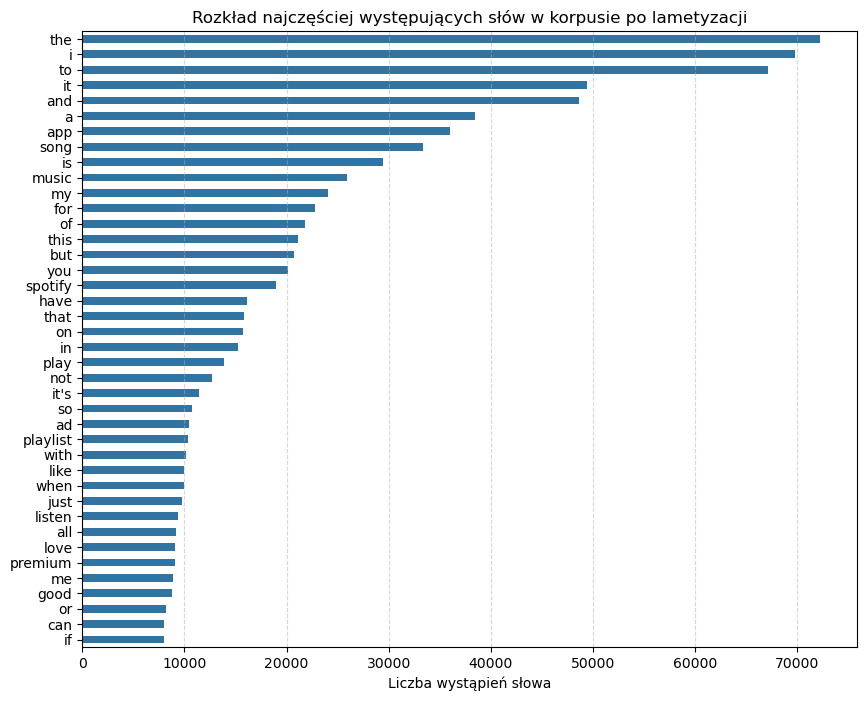

In [30]:
#Analiza korpusu po lametyzacji
corpus_lemma = []
for tokens in spotify['review_lemma']:
    if isinstance(tokens, list):
        corpus_lemma.extend(tokens)

counts_lemma = Counter(corpus_lemma)
most_lemma =counts_lemma.most_common()

first_n = 40
x, y= [], []
for word,count in most_lemma[:first_n]:
        x.append(word)
        y.append(count)

#Stworzenie wykresu najczęściej występujących słów w korpusie
plt.figure(figsize=(10, 8))
sns.barplot(x=y,y=x, width=0.5)
plt.xlabel('Liczba wystąpień słowa')
plt.title('Rozkład najczęściej występujących słów w korpusie po lametyzacji')
plt.grid(axis='x', linestyle='--', alpha=0.5)
print(f"{first_n} najczęściej występujących słów w korpusie")
plt.show()

Tak jak wcześniej wspomniałam w większości są to stopwordsy, czyli słowa, które nie niosą żadnego znaczenia i które wyłączę z dalszej analizy, aby zmniejszyć "szum" podczas modelowania sentymentu.

In [31]:
#Ściągnięcie i podgląd listy stopwords z biblioteki NLTK dla jezyka angielskiego
nltk.download('stopwords')
stop=set(stopwords.words('english'))
print(f"Liczba stopwordów dla języka angielskiego: {len(stop)}")
print(f"Stopword'y z NLTK mają typ {type(stop)} \n")
print(sorted(stop))

Liczba stopwordów dla języka angielskiego: 179
Stopword'y z NLTK mają typ <class 'set'> 

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', 'her', 'here', 'hers', 'herself', 'him', 'himself', 'his', 'how', 'i', 'if', 'in', 'into', 'is', 'isn', "isn't", 'it', "it's", 'its', 'itself', 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'sha

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/mion/s/60/dwisniew/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [32]:
#Modyfikacja listy stopwordsów, usunięcie/dodanie wybranych, które wg mnie mogą mieć wpływ na klasyfikacje - wykonywana iteracyjnie

#Usuwanie wybranych stopwords
stop.difference_update(["don't", "didn't", "doesn't", "can't","couldn't", "isn't"])

#Dodanie wybranych słów do stopwords
stop.update(['spotify', '12', 'wa', 'ha', "i'm", "i've"])

print(sorted(stop))

['12', 'a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', 'd', 'did', 'didn', 'do', 'does', 'doesn', 'doing', 'don', 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'ha', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', 'her', 'here', 'hers', 'herself', 'him', 'himself', 'his', 'how', 'i', "i'm", "i've", 'if', 'in', 'into', 'is', 'isn', 'it', "it's", 'its', 'itself', 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she', "she's", 'should', "should've", 'shouldn', "shouldn't", 'so', 'some', 'spotify', 'such', 't',

In [33]:
spotify['review_lem_stop'] = spotify['review_lemma'].apply(lambda tokens: [word for word in tokens if word not in stop])
spotify.head(5)

,Review,Rating,review_clean,review_tokenised_regex,review_lemma,review_lem_stop
0,"Great music service, the audio is high quality and the app is easy to use. Also very quick and friendly support.",5,great music service the audio is high quality and the app is easy to use also very quick and friendly support,"[great, music, service, the, audio, is, high, quality, and, the, app, is, easy, to, use, also, very, quick, and, friendly, support]","[great, music, service, the, audio, is, high, quality, and, the, app, is, easy, to, use, also, very, quick, and, friendly, support]","[great, music, service, audio, high, quality, app, easy, use, also, quick, friendly, support]"
1,Please ignore previous negative rating. This app is super great. I give it five stars+,5,please ignore previous negative rating this app is super great i give it five stars,"[please, ignore, previous, negative, rating, this, app, is, super, great, i, give, it, five, stars]","[please, ignore, previous, negative, rating, this, app, is, super, great, i, give, it, five, star]","[please, ignore, previous, negative, rating, app, super, great, give, five, star]"
2,"This pop-up ""Get the best Spotify experience on Android 12"" is too annoying. Please let's get rid of this.",4,this pop up get the best spotify experience on android 12 is too annoying please let's get rid of this,"[this, pop, up, get, the, best, spotify, experience, on, android, 12, is, too, annoying, please, let's, get, rid, of, this]","[this, pop, up, get, the, best, spotify, experience, on, android, 12, is, too, annoying, please, let's, get, rid, of, this]","[pop, get, best, experience, android, annoying, please, let's, get, rid]"
3,Really buggy and terrible to use as of recently,1,really buggy and terrible to use as of recently,"[really, buggy, and, terrible, to, use, as, of, recently]","[really, buggy, and, terrible, to, use, a, of, recently]","[really, buggy, terrible, use, recently]"
4,Dear Spotify why do I get songs that I didn't put on my playlist??? And why do we have shuffle play?,1,dear spotify why do i get songs that i didn't put on my playlist and why do we have shuffle play,"[dear, spotify, why, do, i, get, songs, that, i, didn't, put, on, my, playlist, and, why, do, we, have, shuffle, play]","[dear, spotify, why, do, i, get, song, that, i, didn't, put, on, my, playlist, and, why, do, we, have, shuffle, play]","[dear, get, song, didn't, put, playlist, shuffle, play]"


40 najczęściej występujących słów w korpusie


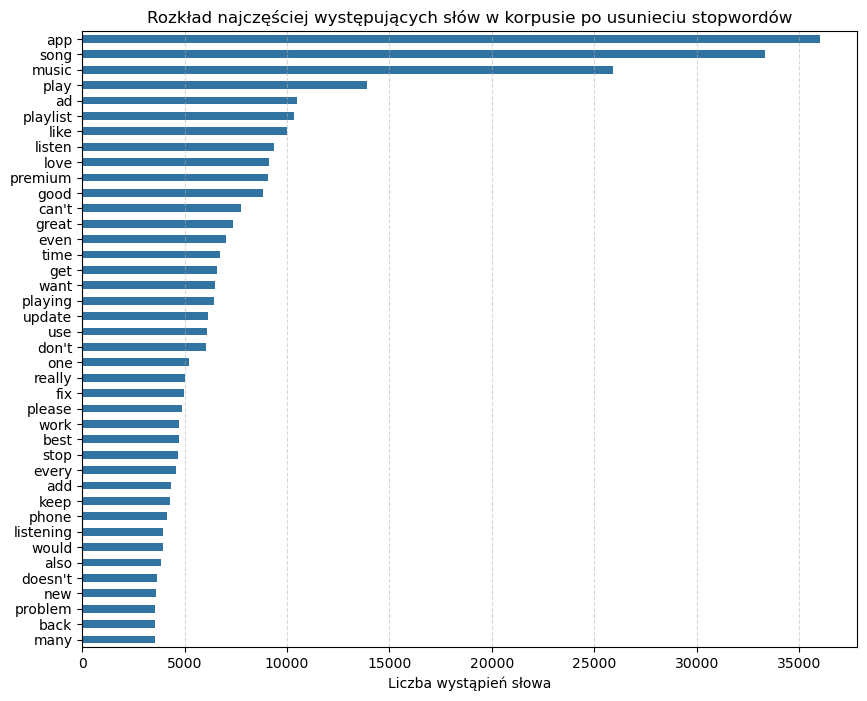

In [34]:
#Analiza korpusu po usunięciu stopwordsów
corpus_lem_stop = []
for tokens in spotify['review_lem_stop']:
    if isinstance(tokens, list):
        corpus_lem_stop.extend(tokens)

counts_lemma_stop = Counter(corpus_lem_stop)
most_lemma_stop =counts_lemma_stop.most_common()

first_n = 40
x, y= [], []
for word,count in most_lemma_stop[:first_n]:
        x.append(word)
        y.append(count)

#Stworzenie wykresu najczęściej występujących słów w korpusie
plt.figure(figsize=(10, 8))
sns.barplot(x=y,y=x, width=0.5)
plt.xlabel('Liczba wystąpień słowa')
plt.title('Rozkład najczęściej występujących słów w korpusie po usunieciu stopwordów')
plt.grid(axis='x', linestyle='--', alpha=0.5)
print(f"{first_n} najczęściej występujących słów w korpusie")
plt.show()

Najczęściej występujące słowa w korpusie niosą znaczenie, co powinno pozytywnie wpłynać na modelowanie sentymentu.

### Modelowanie sentymentu

In [35]:
#Klasyfikacja sentymentu na podstawie ratingu w celu uproszczenia analizy
def assign_sentiment(rating):
    if rating in [5, 4]:
        return 'positive'
    elif rating == 3:
        return 'neutral'
    elif rating in [1, 2]:
        return 'negative'

spotify['sentiment'] = spotify['Rating'].apply(assign_sentiment)

spotify.head(5)

,Review,Rating,review_clean,review_tokenised_regex,review_lemma,review_lem_stop,sentiment
0,"Great music service, the audio is high quality and the app is easy to use. Also very quick and friendly support.",5,great music service the audio is high quality and the app is easy to use also very quick and friendly support,"[great, music, service, the, audio, is, high, quality, and, the, app, is, easy, to, use, also, very, quick, and, friendly, support]","[great, music, service, the, audio, is, high, quality, and, the, app, is, easy, to, use, also, very, quick, and, friendly, support]","[great, music, service, audio, high, quality, app, easy, use, also, quick, friendly, support]",positive
1,Please ignore previous negative rating. This app is super great. I give it five stars+,5,please ignore previous negative rating this app is super great i give it five stars,"[please, ignore, previous, negative, rating, this, app, is, super, great, i, give, it, five, stars]","[please, ignore, previous, negative, rating, this, app, is, super, great, i, give, it, five, star]","[please, ignore, previous, negative, rating, app, super, great, give, five, star]",positive
2,"This pop-up ""Get the best Spotify experience on Android 12"" is too annoying. Please let's get rid of this.",4,this pop up get the best spotify experience on android 12 is too annoying please let's get rid of this,"[this, pop, up, get, the, best, spotify, experience, on, android, 12, is, too, annoying, please, let's, get, rid, of, this]","[this, pop, up, get, the, best, spotify, experience, on, android, 12, is, too, annoying, please, let's, get, rid, of, this]","[pop, get, best, experience, android, annoying, please, let's, get, rid]",positive
3,Really buggy and terrible to use as of recently,1,really buggy and terrible to use as of recently,"[really, buggy, and, terrible, to, use, as, of, recently]","[really, buggy, and, terrible, to, use, a, of, recently]","[really, buggy, terrible, use, recently]",negative
4,Dear Spotify why do I get songs that I didn't put on my playlist??? And why do we have shuffle play?,1,dear spotify why do i get songs that i didn't put on my playlist and why do we have shuffle play,"[dear, spotify, why, do, i, get, songs, that, i, didn't, put, on, my, playlist, and, why, do, we, have, shuffle, play]","[dear, spotify, why, do, i, get, song, that, i, didn't, put, on, my, playlist, and, why, do, we, have, shuffle, play]","[dear, get, song, didn't, put, playlist, shuffle, play]",negative


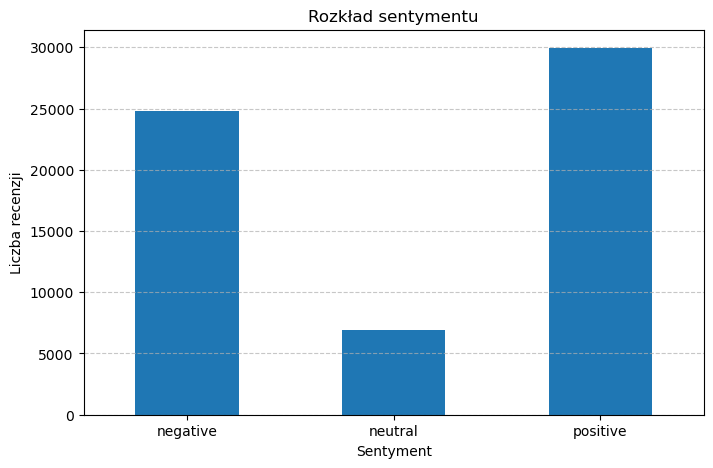

In [36]:
#Rozkład sentymentu
plt.figure(figsize=(8, 5))
spotify['sentiment'].value_counts(sort=False).sort_index().plot(kind='bar')
plt.title("Rozkład sentymentu")
plt.xlabel("Sentyment")
plt.ylabel("Liczba recenzji")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Zdecydowaną większość zbioru stanowią opinie pozytywne i negatywne, neutralne opinie stanowią mniejszość. Mała liczebność opinii neutralnych może utrudniać ich prawidłową klasyfikacje.

In [37]:
#Zdefiniowanie X i y oraz podział danych na zbiór testowy i treningowy
X_data = spotify["review_lem_stop"].copy()
y_data = spotify["sentiment"].copy()

random_state = 33
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.30, random_state=random_state)

train_idx = X_train.index.tolist()
test_idx = X_test.index.tolist()

#### Analiza sentymentu za pomocą TextBlob

In [38]:
#Funkcja przypisująca sentyment recenzji na podstawie polaryzacji tekstu, którą oblicza TextBlob 
def textblob_sentiment(text):
    if isinstance(text, list):
        text = ' '.join(text)
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return 'positive'
    elif polarity == 0:
        return 'neutral'
    elif polarity < 0:
        return 'negative'

In [39]:
#Sprawdzenie etykit w zbiorze testowym
print(y_test.unique())

['positive' 'negative' 'neutral']


In [40]:
#Predykcja dla testowych recenzji - orginalny tekst bez czyszczenia
y_pred_test = list(map(lambda x: textblob_sentiment(x), tqdm(spotify.loc[test_idx]["Review"])))

#dokładność predykcji = (Liczba poprawnych przewidywań) / (Całkowita liczba przewidywań)
print(f"Accuracy dla zbioru testowego: {accuracy_score(y_test, y_pred_test)}")
print(classification_report(y_test, y_pred_test, target_names=['Negative','Neutral', 'Positive']))
print(confusion_matrix(y_test, y_pred_test))

100%|██████████| 18479/18479 [00:05<00:00, 3379.70it/s]


Accuracy dla zbioru testowego: 0.6138319173115429
              precision    recall  f1-score   support

    Negative       0.74      0.43      0.55      7342
     Neutral       0.13      0.12      0.12      2140
    Positive       0.65      0.88      0.75      8997

    accuracy                           0.61     18479
   macro avg       0.51      0.48      0.47     18479
weighted avg       0.63      0.61      0.60     18479

[[3176 1214 2952]
 [ 610  261 1269]
 [ 522  569 7906]]


In [41]:
#Predykcja dla testowych recenzji - oczyszczony tekst
y_pred_test_clean = list(map(lambda x: textblob_sentiment(x), tqdm(spotify.loc[test_idx]["review_clean"])))

print(f"Accuracy dla zbioru testowego: {accuracy_score(y_test, y_pred_test_clean)}")
print(classification_report(y_test, y_pred_test_clean, target_names=['Negative','Neutral', 'Positive']))
print(confusion_matrix(y_test, y_pred_test_clean))

100%|██████████| 18479/18479 [00:05<00:00, 3350.87it/s]


Accuracy dla zbioru testowego: 0.6154553817847286
              precision    recall  f1-score   support

    Negative       0.74      0.43      0.55      7342
     Neutral       0.13      0.12      0.13      2140
    Positive       0.65      0.88      0.75      8997

    accuracy                           0.62     18479
   macro avg       0.51      0.48      0.47     18479
weighted avg       0.63      0.62      0.60     18479

[[3186 1206 2950]
 [ 609  263 1268]
 [ 521  552 7924]]


In [42]:
#Predykcja dla testowych recenzji - tekst po tokenizacji
y_pred_test_tok = list(map(lambda x: textblob_sentiment(x), tqdm(spotify.loc[test_idx]["review_tokenised_regex"])))

print(f"Accuracy dla zbioru testowego: {accuracy_score(y_test, y_pred_test_tok)}")
print(classification_report(y_test, y_pred_test_tok, target_names=['Positive','Neutral','Negative']))
print(confusion_matrix(y_test, y_pred_test_tok))

100%|██████████| 18479/18479 [00:04<00:00, 3703.76it/s]


Accuracy dla zbioru testowego: 0.6148601114778939
              precision    recall  f1-score   support

    Positive       0.74      0.43      0.55      7342
     Neutral       0.13      0.12      0.13      2140
    Negative       0.65      0.88      0.75      8997

    accuracy                           0.61     18479
   macro avg       0.51      0.48      0.47     18479
weighted avg       0.63      0.61      0.60     18479

[[3168 1214 2960]
 [ 603  265 1272]
 [ 512  556 7929]]


In [43]:
#Predykcja dla testowych recenzji - tekst po lametyzacji
y_pred_test_lemma = list(map(lambda x: textblob_sentiment(x), tqdm(spotify.loc[test_idx]["review_lemma"])))

print(f"Accuracy dla zbioru testowego: {accuracy_score(y_test, y_pred_test_lemma)}")
print(classification_report(y_test, y_pred_test_lemma, target_names=['Negative','Neutral', 'Positive']))
print(confusion_matrix(y_test, y_pred_test_lemma))

100%|██████████| 18479/18479 [00:05<00:00, 3695.65it/s]


Accuracy dla zbioru testowego: 0.6128578386276313
              precision    recall  f1-score   support

    Negative       0.74      0.42      0.54      7342
     Neutral       0.13      0.12      0.12      2140
    Positive       0.65      0.88      0.75      8997

    accuracy                           0.61     18479
   macro avg       0.50      0.48      0.47     18479
weighted avg       0.62      0.61      0.59     18479

[[3113 1224 3005]
 [ 596  252 1292]
 [ 509  528 7960]]


100%|██████████| 18479/18479 [00:05<00:00, 3684.23it/s]


Accuracy dla zbioru testowego: 0.6018723956924076
              precision    recall  f1-score   support

    Negative       0.74      0.40      0.52      7342
     Neutral       0.13      0.14      0.14      2140
    Positive       0.65      0.88      0.75      8997

    accuracy                           0.60     18479
   macro avg       0.51      0.47      0.47     18479
weighted avg       0.62      0.60      0.58     18479

[[2919 1420 3003]
 [ 535  309 1296]
 [ 486  617 7894]]


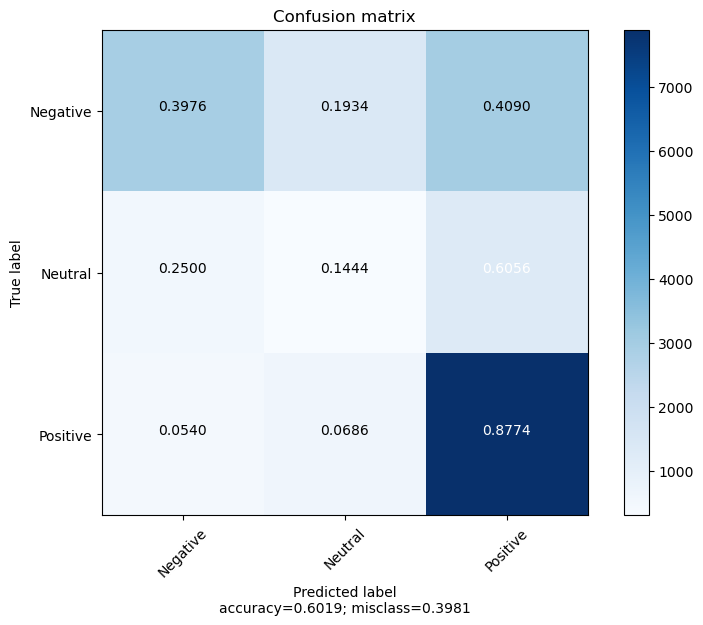

In [65]:
#Predykcja dla testowych recenzji - tekst po usunieciu stopwordsów
y_pred_test_stop = list(map(lambda x: textblob_sentiment(x), tqdm(spotify.loc[test_idx]["review_lem_stop"])))

print(f"Accuracy dla zbioru testowego: {accuracy_score(y_test, y_pred_test_stop)}")
print(classification_report(y_test, y_pred_test_stop, target_names=['Negative','Neutral', 'Positive']))
print(confusion_matrix(y_test, y_pred_test_stop))
#plot_confusion_matrix.plot_confusion_matrix(confusion_matrix(y_test, y_pred_test_stop), target_names=['Negative','Neutral', 'Positive']) #na potrzeby prezentacji

#### Modelowanie - naiwny klasyfikator bayesowski

##### reprezentacja tekstu - Bag of Word (BoW)

In [45]:
#Reprezentacja tekstu metodą BoW
def do_nothing(tokens):
    return tokens

bow_count_BoW = CountVectorizer(tokenizer=do_nothing,
                             preprocessor=None,
                             lowercase=False)

X_train_bow_count = bow_count_BoW.fit_transform(X_train)
X_test_bow_count = bow_count_BoW.transform(X_test)

#Modelowanie bayesowskie
clf = MultinomialNB()
clf.fit(X_train_bow_count, y_train)

#Predykcja
y_train_pred = clf.predict(X_train_bow_count)
y_test_pred = clf.predict(X_test_bow_count)

#Accuracy dla zbioru testowego i treningowego - ocena wyników
multiNB_bow_train_score = accuracy_score(y_train, y_train_pred)
multiNB_bow_test_score = accuracy_score(y_test, y_test_pred)
print(f"Accuracy dla zbioru treningowego: {multiNB_bow_train_score}")
print(f"Accuracy dla zbioru testowego: {multiNB_bow_test_score}")

#Raport klasyfikacji
print(classification_report(y_test, y_test_pred, target_names=['Negative','Neutral', 'Positive']))

/opt/conda/envs/DataScience/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Accuracy dla zbioru treningowego: 0.8036878116664734
Accuracy dla zbioru testowego: 0.7719573569998377
              precision    recall  f1-score   support

    Negative       0.71      0.88      0.79      7342
     Neutral       0.31      0.05      0.09      2140
    Positive       0.85      0.86      0.85      8997

    accuracy                           0.77     18479
   macro avg       0.62      0.60      0.58     18479
weighted avg       0.73      0.77      0.74     18479



In [46]:
project_path = "/home/mion/s/60/dwisniew/TM_in_python_PW-main"
sys.path.append(project_path)

In [47]:
from utils import plot_confusion_matrix

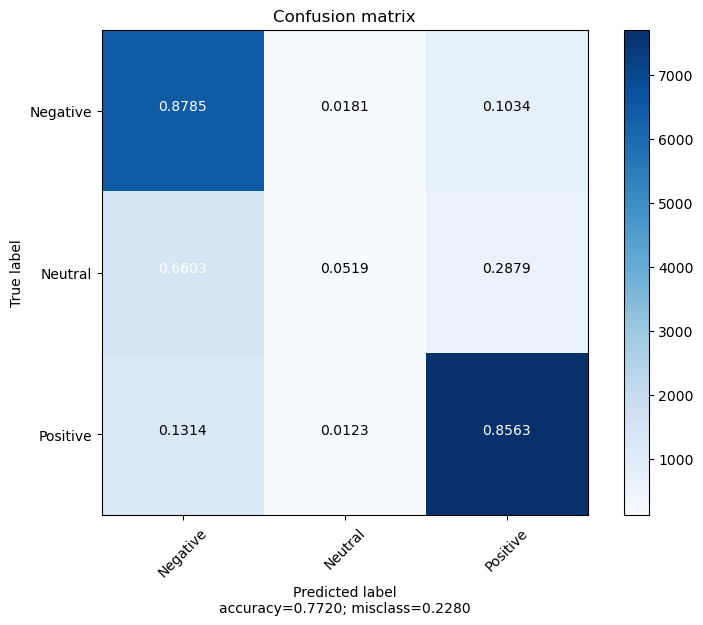

In [48]:
#Macierz pomyłek
plot_confusion_matrix.plot_confusion_matrix(confusion_matrix(y_test, y_test_pred), target_names=['Negative','Neutral', 'Positive'])

##### reprezentacja tekstu - n-gram

In [49]:
#Reprezentacja tekstu metodą n-gram
bow_count_ngram = CountVectorizer(ngram_range=(1, 2), 
                            tokenizer=do_nothing,
                             preprocessor=None,
                             lowercase=False)

X_train_bow_count = bow_count_ngram.fit_transform(X_train)
X_test_bow_count = bow_count_ngram.transform(X_test)

#Modelowanie bayesowskie
clf = MultinomialNB()
clf.fit(X_train_bow_count, y_train)

#Predykcja
y_train_pred = clf.predict(X_train_bow_count)
y_test_pred = clf.predict(X_test_bow_count)

#Accuracy dla zbioru testowego i treningowego - ocena wyników
multiNB_bow_train_score = accuracy_score(y_train, y_train_pred)
multiNB_bow_test_score = accuracy_score(y_test, y_test_pred)
print(f"Accuracy dla zbioru treningowego: {multiNB_bow_train_score}")
print(f"Accuracy dla zbioru testowego: {multiNB_bow_test_score}")

#Raport klasyfikacji
print(classification_report(y_test, y_test_pred, target_names=['Negative','Neutral', 'Positive']))

/opt/conda/envs/DataScience/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Accuracy dla zbioru treningowego: 0.8761219993041864
Accuracy dla zbioru testowego: 0.7821310676984685
              precision    recall  f1-score   support

    Negative       0.70      0.92      0.80      7342
     Neutral       0.29      0.00      0.00      2140
    Positive       0.87      0.85      0.86      8997

    accuracy                           0.78     18479
   macro avg       0.62      0.59      0.55     18479
weighted avg       0.74      0.78      0.74     18479



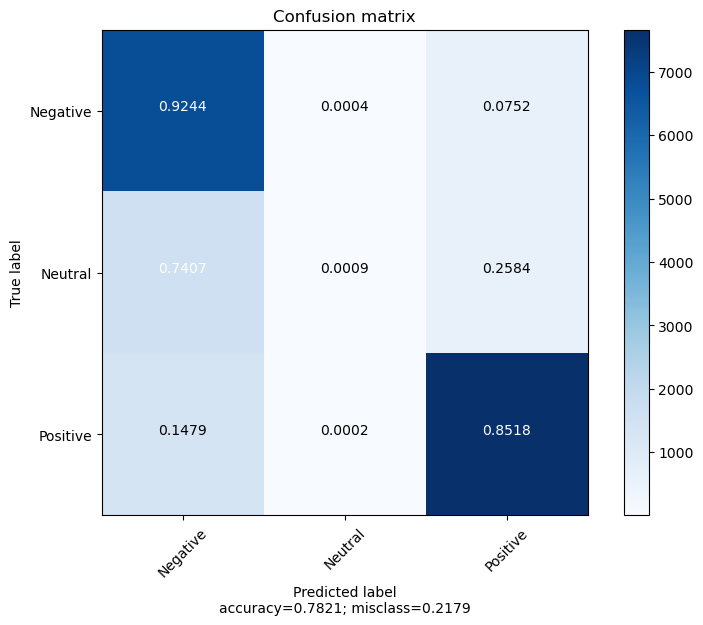

In [50]:
plot_confusion_matrix.plot_confusion_matrix(confusion_matrix(y_test, y_test_pred), target_names=['Negative','Neutral', 'Positive'])

##### reprezentacja tekstu - TF-IDF

In [51]:
#Reprezentacja tekstu metodą TF-IDF
tfidf = TfidfTransformer(use_idf=True, norm='l2', smooth_idf=True)

X_train_tfidf = tfidf.fit_transform(X_train_bow_count)
X_test_tfidf = tfidf.transform(X_test_bow_count)

#Modelowanie bayesowskie
clf = MultinomialNB()
clf.fit(X_train_tfidf, y_train)

#Predykcja
y_train_pred = clf.predict(X_train_tfidf)
y_test_pred = clf.predict(X_test_tfidf)

#Accuracy dla zbioru testowego i treningowego - ocena wyników
multiNB_bow_train_score = accuracy_score(y_train, y_train_pred)
multiNB_bow_test_score = accuracy_score(y_test, y_test_pred)
print(f"Accuracy dla zbioru treningowego: {multiNB_bow_train_score}")
print(f"Accuracy dla zbioru testowego: {multiNB_bow_test_score}")

#Raport klasyfikacji
print(classification_report(y_test, y_test_pred, target_names=['Negative','Neutral', 'Positive']))

Accuracy dla zbioru treningowego: 0.8312188333526614
Accuracy dla zbioru testowego: 0.7822934141457871


/opt/conda/envs/DataScience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

    Negative       0.71      0.91      0.80      7342
     Neutral       0.00      0.00      0.00      2140
    Positive       0.86      0.86      0.86      8997

    accuracy                           0.78     18479
   macro avg       0.52      0.59      0.55     18479
weighted avg       0.70      0.78      0.74     18479



/opt/conda/envs/DataScience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/envs/DataScience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


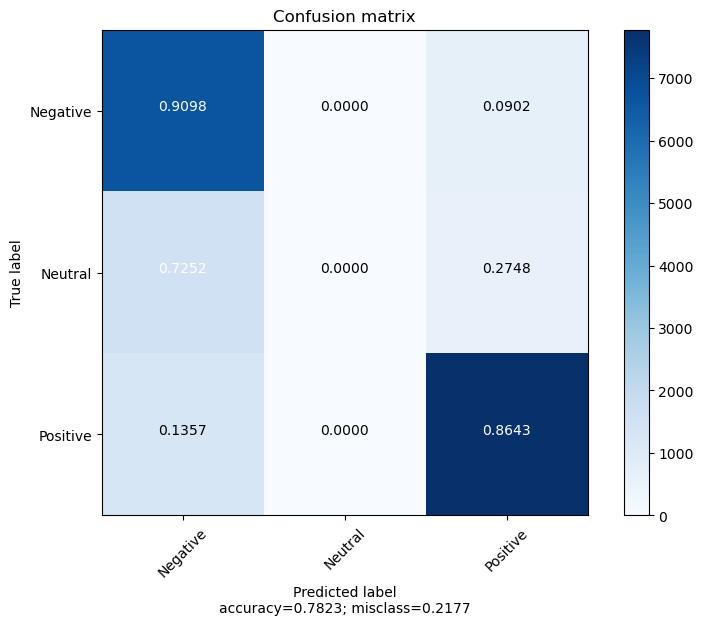

In [52]:
plot_confusion_matrix.plot_confusion_matrix(confusion_matrix(y_test, y_test_pred), target_names=['Negative','Neutral', 'Positive'])

Najlepszym modelem bayesowskim wydaje się być ten, w którym tekst jest reprezentowany przez BoW, ze względu na to, że ma dość wysoką wartość accuracy (0,77) i jakkolwiek uwzględnia sentyment opinii neutralnych (macierz pomyłek, wartość f1-score).

#### Modelowanie - regresja logistyczna

##### reprezentacja tekstu - Bag of Word (BoW)

In [53]:
#Reprezentacja tekstu metodą BoW
X_train_bow_count = bow_count_BoW.fit_transform(X_train)
X_test_bow_count = bow_count_BoW.transform(X_test)

y_train_encoded = y_train.map({'positive': 0, 'neutral': 1, 'negative': 2})
y_test_encoded = y_test.map({'positive': 0, 'neutral': 1, 'negative': 2})

#Model regresji logistycznej
clf = LogisticRegression(multi_class='multinomial')
clf.fit(X_train_bow_count, y_train_encoded)

#Predykcja
y_train_pred = clf.predict(X_train_bow_count)
y_test_pred = clf.predict(X_test_bow_count)

#Accuracy dla zbioru testowego i treningowego - ocena wyników
train_score = accuracy_score(y_train_encoded, y_train_pred)
test_score = accuracy_score(y_test_encoded, y_test_pred)
print(f"Accuracy dla zbioru treningowego: {train_score}")
print(f"Accuracy dla zbioru testowego: {test_score}")

#Raport klasyfikacji
print(classification_report(y_test_encoded, y_test_pred, target_names=['Positive','Neutral','Negative']))

/opt/conda/envs/DataScience/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/conda/envs/DataScience/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy dla zbioru treningowego: 0.851513394410298
Accuracy dla zbioru testowego: 0.769738622219817
              precision    recall  f1-score   support

    Positive       0.82      0.88      0.85      8997
     Neutral       0.32      0.11      0.17      2140
    Negative       0.75      0.83      0.79      7342

    accuracy                           0.77     18479
   macro avg       0.63      0.61      0.60     18479
weighted avg       0.74      0.77      0.75     18479



/opt/conda/envs/DataScience/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


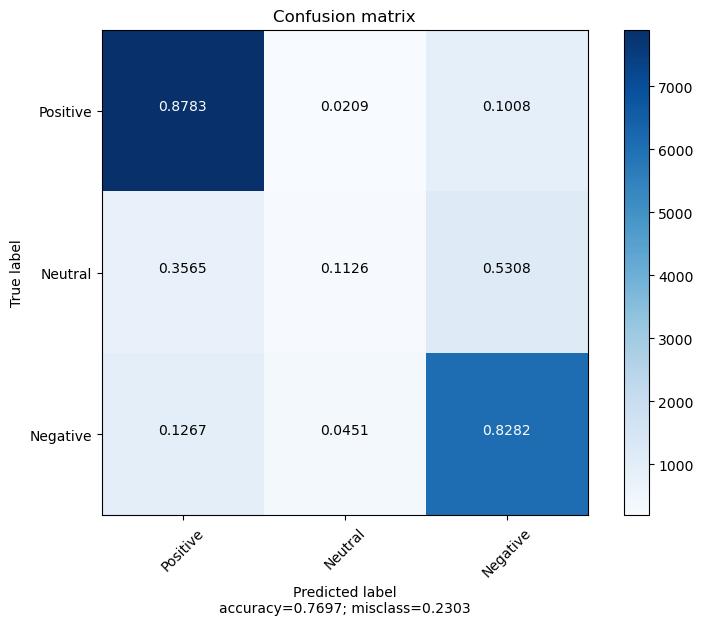

In [54]:
plot_confusion_matrix.plot_confusion_matrix(confusion_matrix(y_test_encoded, y_test_pred), target_names=['Positive','Neutral','Negative'])

##### reprezentacja tekstu - n-gram

In [55]:
#Reprezentacja tekstu metodą n-gram
X_train_bow_count = bow_count_ngram.fit_transform(X_train)
X_test_bow_count = bow_count_ngram.transform(X_test)

#Zakodowanie etykiet klas
y_train_encoded = y_train.map({'positive': 0, 'neutral': 1, 'negative': 2})
y_test_encoded = y_test.map({'positive': 0, 'neutral': 1, 'negative': 2})

#Model regresji logistycznej
clf = LogisticRegression(multi_class='multinomial')
clf.fit(X_train_bow_count, y_train_encoded)

#Predykcja
y_train_pred = clf.predict(X_train_bow_count)
y_test_pred = clf.predict(X_test_bow_count)

#Accuracy dla zbioru testowego i treningowego - ocena wyników
train_score = accuracy_score(y_train_encoded, y_train_pred)
test_score = accuracy_score(y_test_encoded, y_test_pred)
print(f"Accuracy dla zbioru treningowego: {train_score}")
print(f"Accuracy dla zbioru testowego: {test_score}")

#Raport klasyfikacji
print(classification_report(y_test_encoded, y_test_pred, target_names=['Positive','Neutral','Negative']))

/opt/conda/envs/DataScience/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/conda/envs/DataScience/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy dla zbioru treningowego: 0.9899107039313464
Accuracy dla zbioru testowego: 0.7801287948482061
              precision    recall  f1-score   support

    Positive       0.84      0.88      0.86      8997
     Neutral       0.33      0.13      0.18      2140
    Negative       0.76      0.84      0.80      7342

    accuracy                           0.78     18479
   macro avg       0.64      0.62      0.61     18479
weighted avg       0.75      0.78      0.76     18479



/opt/conda/envs/DataScience/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


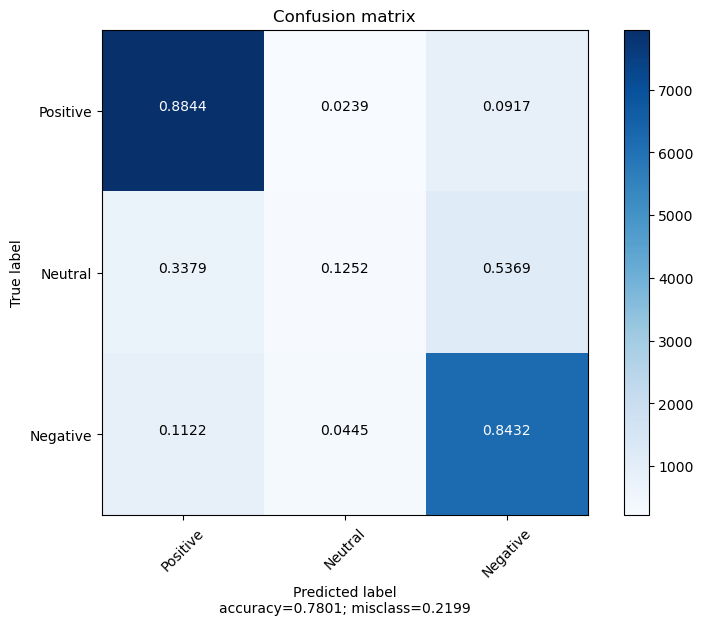

In [56]:
plot_confusion_matrix.plot_confusion_matrix(confusion_matrix(y_test_encoded, y_test_pred), target_names=['Positive','Neutral','Negative'])

##### reprezentacja tekstu - TF-IDF

In [57]:
#Reprezentacja tekstu metodą TF-IDF
X_train_tfidf = tfidf.fit_transform(X_train_bow_count)
X_test_tfidf = tfidf.transform(X_test_bow_count)

y_train_encoded = y_train.map({'positive': 0, 'neutral': 1, 'negative': 2})
y_test_encoded = y_test.map({'positive': 0, 'neutral': 1, 'negative': 2})

#Model regresji logistycznej
clf = LogisticRegression(multi_class='multinomial')
clf.fit(X_train_tfidf, y_train_encoded)

#Predykcja
y_train_pred = clf.predict(X_train_tfidf)
y_test_pred = clf.predict(X_test_tfidf)

#Accuracy dla zbioru testowego i treningowego - ocena wyników
train_score = accuracy_score(y_train_encoded, y_train_pred)
test_score = accuracy_score(y_test_encoded, y_test_pred)
print(f"Accuracy dla zbioru treningowego: {train_score}")
print(f"Accuracy dla zbioru testowego: {test_score}")

#Raport klasyfikacji
print(classification_report(y_test_encoded, y_test_pred, target_names=['Positive','Neutral','Negative']))

/opt/conda/envs/DataScience/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy dla zbioru treningowego: 0.8678418183926707
Accuracy dla zbioru testowego: 0.7904648519941555
              precision    recall  f1-score   support

    Positive       0.86      0.88      0.87      8997
     Neutral       0.47      0.05      0.09      2140
    Negative       0.73      0.90      0.81      7342

    accuracy                           0.79     18479
   macro avg       0.69      0.61      0.59     18479
weighted avg       0.76      0.79      0.75     18479



/opt/conda/envs/DataScience/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


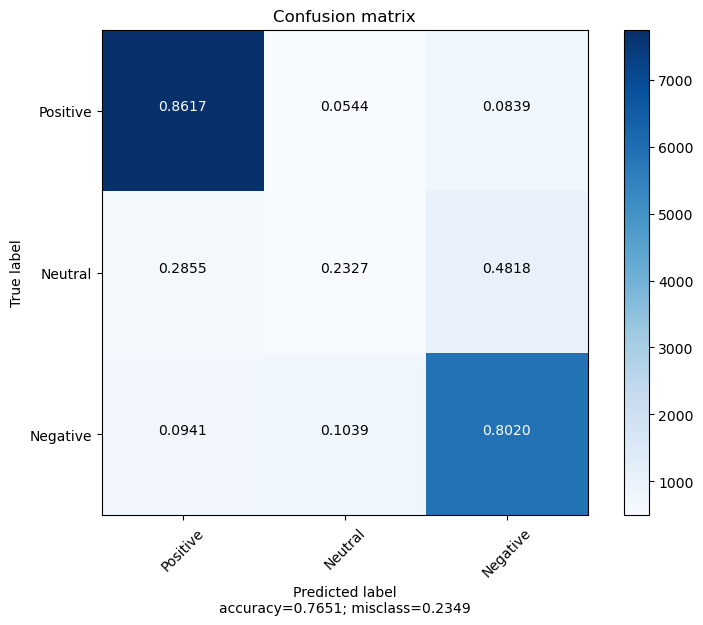

In [66]:
plot_confusion_matrix.plot_confusion_matrix(confusion_matrix(y_test_encoded, y_test_pred), target_names=['Positive','Neutral','Negative'])

Najlepszym modelem regresji logistycznej wydaje się być ten, w którym tekst jest reprezentowany przez n-gramy, ze względu na to, że ma dość wysoką wartość accuracy dla danych testowych (0.78) uwzględniając przy tym najlepiej sentyment opinii neutralnych (macierz pomyłek, wartość f1-score).

#### Modyfikacje najlepszych modeli

##### Model bayesowski z reprezentacją tekstu za pomocą BoW + najlepsza alpha

In [59]:
#Reprezentacja tekstu metodą BoW
X_train_bow_count = bow_count_BoW.fit_transform(X_train)
X_test_bow_count = bow_count_BoW.transform(X_test)

#Znalezienie najlepszej alfy
tuned_parameters = [{'alpha' : [0.7, 1.0, 1.5, 2]}]
cv = ShuffleSplit(n_splits=3, test_size=0.3, random_state=0)

clf = GridSearchCV(MultinomialNB(), tuned_parameters, cv=cv, scoring='accuracy')
clf.fit(X_train_bow_count, y_train)

print("Najlepszy parametr:", clf.best_params_)
print("Wyniki accuracy walidacji krzyżowej dla danej alfy:", clf.cv_results_["mean_test_score"])

/opt/conda/envs/DataScience/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Najlepszy parametr: {'alpha': 2}
Wyniki accuracy walidacji krzyżowej dla danej alfy: [0.76814843 0.77240046 0.77453936 0.77518361]


In [60]:
#Modelowanie bayesowskie
clf = MultinomialNB(alpha = 2)
clf.fit(X_train_bow_count, y_train)

#Predykcja
y_train_pred = clf.predict(X_train_bow_count)
y_test_pred = clf.predict(X_test_bow_count)

#Accuracy dla zbioru testowego i treningowego - ocena wyników
multiNB_bow_train_score = accuracy_score(y_train, y_train_pred)
multiNB_bow_test_score = accuracy_score(y_test, y_test_pred)
print(f"Accuracy dla zbioru treningowego: {multiNB_bow_train_score}")
print(f"Accuracy dla zbioru testowego: {multiNB_bow_test_score}")

#Raport klasyfikacji
print(classification_report(y_test, y_test_pred, target_names=['Negative','Neutral', 'Positive']))

Accuracy dla zbioru treningowego: 0.7923692450423286
Accuracy dla zbioru testowego: 0.7732561285783863
              precision    recall  f1-score   support

    Negative       0.70      0.90      0.79      7342
     Neutral       0.24      0.01      0.02      2140
    Positive       0.85      0.86      0.85      8997

    accuracy                           0.77     18479
   macro avg       0.60      0.59      0.55     18479
weighted avg       0.72      0.77      0.73     18479



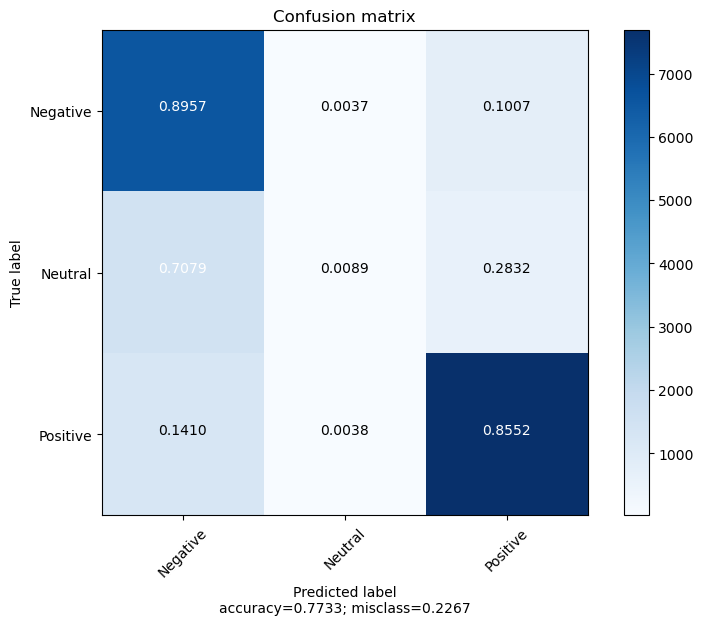

In [61]:
plot_confusion_matrix.plot_confusion_matrix(confusion_matrix(y_test, y_test_pred), target_names=['Negative','Neutral', 'Positive'])

Zastosowane modyfikacje spowodowały zmniejszenie poprawności klasyfikacji opinii neutralnych (f1-score: 0.09 -> 0.02) bez znaczącej poprawy miar dla pozostałych klas.

##### Model regresji logistycznej z reprezentacją tekstu za pomocą n-gram + balansowanie wag klas + najlepsze C

In [62]:
#Reprezentacja tekstu metodą n-gram
X_train_bow_count = bow_count_ngram.fit_transform(X_train)
X_test_bow_count = bow_count_ngram.transform(X_test)

y_train_encoded = y_train.map({'positive': 0, 'neutral': 1, 'negative': 2})
y_test_encoded = y_test.map({'positive': 0, 'neutral': 1, 'negative': 2})

tuned_parameters = {'C': [0.1, 0.5, 1, 3]} #im większe C tym model jest bardziej przeuczony dlatego sprawdzam względnie małe wartości
cv = ShuffleSplit(n_splits=3, test_size=0.3, random_state=0)

clf = GridSearchCV(LogisticRegression(multi_class='multinomial', class_weight='balanced'), 
                   tuned_parameters, 
                   cv=cv, 
                   scoring='accuracy')

clf.fit(X_train_bow_count, y_train_encoded)

print("Najlepszy parametr:", clf.best_params_)
print("Wyniki accuracy walidacji krzyżowej dla danego C:", clf.cv_results_["mean_test_score"])

/opt/conda/envs/DataScience/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/conda/envs/DataScience/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/conda/envs/DataScience/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/conda/envs/DataScience/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From th

Najlepszy parametr: {'C': 0.5}
Wyniki accuracy walidacji krzyżowej dla danego C: [0.76369025 0.76742688 0.76727226 0.76482412]


/opt/conda/envs/DataScience/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [63]:
#Model regresji logistycznej
clf = LogisticRegression(multi_class='multinomial', class_weight = 'balanced', C = 0.5)
clf.fit(X_train_bow_count, y_train_encoded)

#Predykcja
y_train_pred = clf.predict(X_train_bow_count)
y_test_pred = clf.predict(X_test_bow_count)

#Accuracy dla zbioru testowego i treningowego - ocena wyników
train_score = accuracy_score(y_train_encoded, y_train_pred)
test_score = accuracy_score(y_test_encoded, y_test_pred)
print(f"Accuracy dla zbioru treningowego: {train_score}")
print(f"Accuracy dla zbioru testowego: {test_score}")

#Raport klasyfikacji
print(classification_report(y_test_encoded, y_test_pred, target_names=['Positive','Neutral','Negative']))

/opt/conda/envs/DataScience/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy dla zbioru treningowego: 0.9829525687115853
Accuracy dla zbioru testowego: 0.7651388062124573
              precision    recall  f1-score   support

    Positive       0.86      0.86      0.86      8997
     Neutral       0.28      0.23      0.26      2140
    Negative       0.77      0.80      0.78      7342

    accuracy                           0.77     18479
   macro avg       0.64      0.63      0.63     18479
weighted avg       0.75      0.77      0.76     18479



/opt/conda/envs/DataScience/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


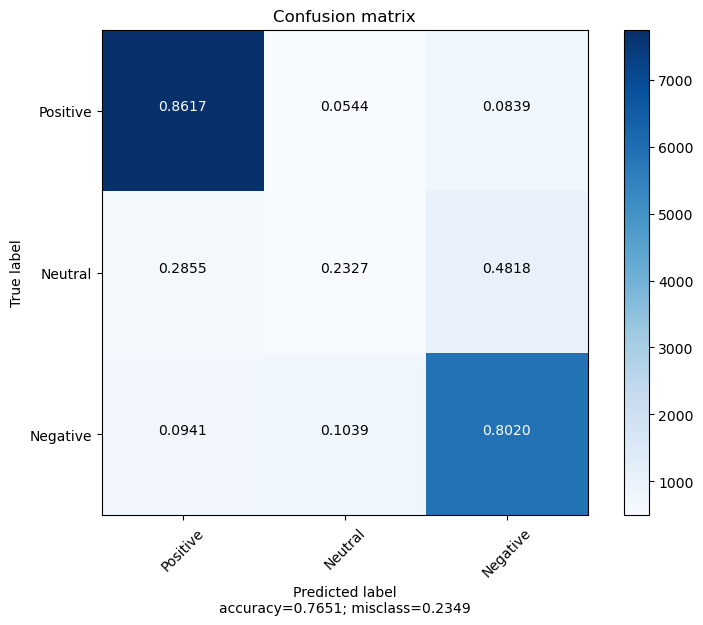

In [64]:
plot_confusion_matrix.plot_confusion_matrix(confusion_matrix(y_test_encoded, y_test_pred), target_names=['Positive','Neutral','Negative'])

Zastosowane modyfikacje spowodowały zwiększenie poprawności klasyfikacji opinii neutralnych (f1-score: 0.18 -> 0.26) bez znaczącej zmiany miar dla pozostałych klas.

#### Wnioski

TextBlob we wszystkich przypadkach daje podobny wynik accuracy, co sugeruje, że przetwarzanie tekstu nie znacznie wpływają na jego analizę sentymentu. Klasyfikacja na podstawie wartości polaryzacji najlepiej się sprawdza do klasyfikowania opinii pozytywnych, negatywne i neutralne bardzo słabo klasyfikuje

Modele bayesowskie i regresji logistycznej dobrze klasyfikują pozytywne i negatywne opinie jednak słabo sobie radzą z neutralnymi

Modele z reprezentacją tekstu typu TF-IDF najgorzej sobie radzą z klasyfikacją opinii neutralnych

Najlepszym modelem z uzyskanych wydaje się być zmodyfikowany model regresji logistycznej z reprezentacją tekstu za pomocą N-gram jednak wciąż on nie klasyfikuje poprawnie nawet w 50% opinii neutralnych

#### Propozycja innych modyfikacji

Szczegółowa analiza opinii neutrlanych w celu zwiększenia poprawności ich klasyfikacji przez modele

Zastosowanie wag w modelach bayesowskich – MultinomialNB() nie posiada wbudowanego parametru automatycznie balansującego wagi klas, trzeba je ustawić ręcznie

Modyfikacja innych parametów modeli w celu ich optymalizacji

Zmiana klasyfikacji sentymentu - zwiększenie liczebności opinii neutralnych poprzez inny podział sentymentu na podstawie ratingu